In [3]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv("data_traj_escalade_v1.5.csv", sep=";", decimal=",")
time = data["Time"]
x = data["Marqueur 1/0/X"]
y = data["Marqueur 1/0/Y"]

from scipy.spatial import ConvexHull

df_traj = data[:3433]

points = df_traj[['Marqueur 1/0/X', 'Marqueur 1/0/Y']].to_numpy()

hull = ConvexHull(points)
perimeter_convex_hull = np.sum(np.sqrt(np.sum(np.diff(points[hull.vertices], axis=0)**2, axis=1)))

L_T = np.sum(np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1)))

GIE = (np.log(2 * L_T) - np.log(perimeter_convex_hull)) / np.log(2)

perimeter_convex_hull, L_T, GIE

(np.float64(1585.6137269976775),
 np.float64(3415.002830737387),
 np.float64(2.106845416972228))

In [5]:
# j'identifie la montée et la descente en obtenant les index de la coordonnées y (axe vertical) la plus haute atteinte.
np.where(data["Marqueur 1/0/Y"] == np.max(data["Marqueur 1/0/Y"]))

(array([3429, 3430, 3431, 3432]),)

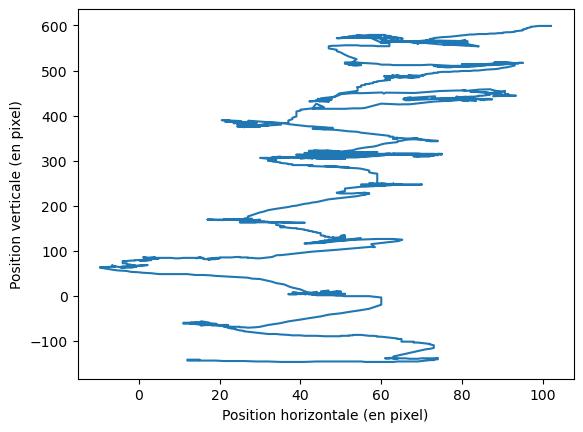

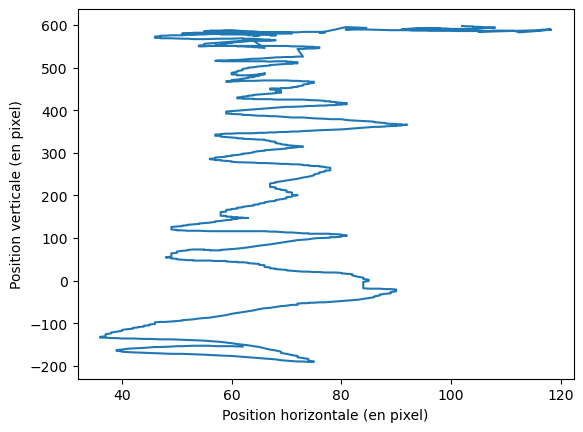

In [6]:
plt.plot(x[:3433], y[:3433])
plt.xlabel("Position horizontale (en pixel)")
plt.ylabel("Position verticale (en pixel)")
plt.savefig("traj_montee.svg")
plt.show()
plt.plot(x[3433:], y[3433:])
plt.xlabel("Position horizontale (en pixel)")
plt.ylabel("Position verticale (en pixel)")
plt.savefig("traj_descente.svg")

## La vitesse

(np.float64(0.07719231166616665), np.float64(0.4135565560751317))

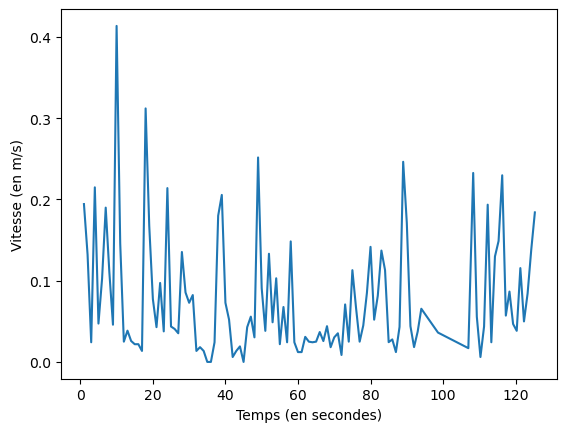

In [9]:
i = 0
vitesses_par_seconde = []
time_v = []
# 3402 = fin de la montée-30
while i <= 3402:
    time_a, x_a, y_a = data.iloc[i]
    time_b, x_b, y_b = data.iloc[i+30]
    dist_en_cm = (np.sqrt((x_b-x_a)**2+(y_a-y_b)**2))/1.6542
    vitesses_par_seconde.append(dist_en_cm/(time_b-time_a)) # vitesse en cm/s
    time_v.append(time.iloc[i+30])
    i+=30

plt.plot(time_v, np.array(vitesses_par_seconde)/100)
plt.xlabel("Temps (en secondes)")
plt.ylabel("Vitesse (en m/s)")
plt.savefig("speed.svg")

v_mo = np.mean(np.array(vitesses_par_seconde))/100 # vitesse moyenne en m/s
v_ma = np.max(np.array(vitesses_par_seconde)[:3433]/100) # vitesse maximum lors de la montée en m/s
v_mo, v_ma

## Temps d'escalade

In [7]:
time[3432]

np.float64(125.648)

## Ratio temps de mouvements sur temps d'immobilité

In [8]:
def isclose(a, b, trsh):
    return abs(a-b)<trsh
trsh = 1
index_deb = time[(isclose(time, 11.23, trsh))]
index_fin = time[(isclose(time, 17.33, trsh))]
while len(index_deb) > 1:
    trsh/=10
    index_deb = time[(isclose(time, 11.23, trsh))]
trsh = 1
while len(index_fin) > 1:
    trsh/=10
    index_fin = time[(isclose(time, 17.33, trsh))]
index_deb = index_deb.index[0]
index_fin = index_fin.index[0]
index_deb, index_fin

(np.int64(337), np.int64(520))

In [9]:
i = 0
dist_imo = []
while i < len(data[index_deb:(index_fin+1)])-30:
    time_a, x_a, y_a = data.iloc[i]
    time_b, x_b, y_b = data.iloc[i+30]
    dist_imo.append((np.sqrt((x_b-x_a)**2+(y_a-y_b)**2))/1.6542)
    i+=30
trsh = np.mean(np.array(dist_imo))
trsh

np.float64(11.916358817123998)

In [10]:
i = 0
mouvement = []
while i <= (len(time)-30):
    time_a, x_a, y_a = data.iloc[i]
    time_b, x_b, y_b = data.iloc[i+30]
    dist_en_cm = (np.sqrt((x_b-x_a)**2+(y_a-y_b)**2))/1.6542
    if dist_en_cm > trsh:
        mouvement.append(True)
    else:
        mouvement.append(False)
    i+=30
mouvement_def = []
for j in mouvement:
    for k in range(30):
        mouvement_def.append(j)
if i < len(time):
    diff = len(time)-i
    for j in range(diff):
        mouvement_def.append(mouvement_def[-1])
f"{round(((len(time[(np.array(mouvement_def))])*0.033)-0.033)/(time[3432])*100, 2)} %"

'43.13 %'

## Hauteur du mur

In [15]:
(np.mean(np.array(vitesses_par_seconde))/100)*(time[3432])

np.float64(9.699059576230507)